### Python for Computer Science and Data Science 2 (CSE 3652)
##### MAJOR ASSIGNMENT-3: MACHINE LEARNING- CLASSIFICATION, REGRESSION AND CLUSTERING

![My Image](Images/9.png)

### Tasks

![My Image](Images/10.png)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)
Flattened Training Shape: (60000, 784)
Flattened Testing Shape: (10000, 784)
Missing values in training set: 0
Missing values in testing set: 0


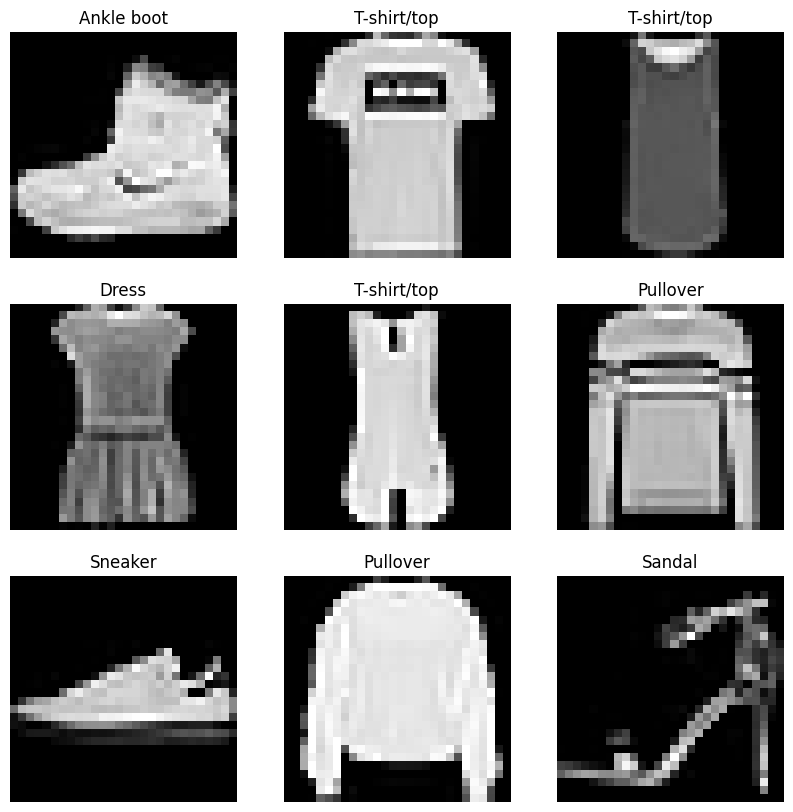

In [ ]:
# =========================
# TASK 1: DATA PREPROCESSING
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Display dataset shape
print("Training Data Shape:", train_images.shape)
print("Testing Data Shape:", test_images.shape)

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images from 28x28 to 784
train_images_flat = train_images.reshape((60000, 784))
test_images_flat = test_images.reshape((10000, 784))

print("Flattened Training Shape:", train_images_flat.shape)
print("Flattened Testing Shape:", test_images_flat.shape)

# Check missing values
print("Missing values in training set:", np.isnan(train_images_flat).sum())
print("Missing values in testing set:", np.isnan(test_images_flat).sum())

# Display sample images
class_names=['T-shirt/top', 'Trouser', 'Pullover', 'Dress',
            'Coat', 'Sandal', 'Shirt', 'Sneaker',
            'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.show()

![My Image](Images/11.png)

In [ ]:
# =========================
# TASK 2: KNN CLASSIFICATION
# =========================

import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images
train_images_flat = train_images.reshape((60000, 784))
test_images_flat = test_images.reshape((10000, 784))

# Different k values
k_values = [3, 5, 7]

# Train and evaluate KNN
for k in k_values:

    print(f"\nTraining KNN with k = {k}")

    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(train_images_flat, train_labels)

    # Predict test data
    predictions = knn.predict(test_images_flat)

    # Calculate accuracy
    accuracy = accuracy_score(test_labels, predictions)

    print(f"Accuracy for k={k}: {accuracy:.4f}")


Training KNN with k = 3
Accuracy for k=3: 0.8541

Training KNN with k = 5
Accuracy for k=5: 0.8554

Training KNN with k = 7
Accuracy for k=7: 0.8540


![My Image](Images/12.png)

In [ ]:
# =========================
# TASK 3: SVM CLASSIFICATION
# =========================

import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images
train_images_flat = train_images.reshape((60000, 784))
test_images_flat = test_images.reshape((10000, 784))

# Kernels to test
kernels = ['linear', 'poly', 'rbf']

# Train and evaluate SVM
for kernel in kernels:

    print(f"\nTraining SVM with {kernel} kernel")

    # Create SVM model
    svm = SVC(kernel=kernel, C=1)

    # Train model
    svm.fit(train_images_flat, train_labels)

    # Predict test data
    predictions = svm.predict(test_images_flat)

    # Calculate accuracy
    accuracy = accuracy_score(test_labels, predictions)

    print(f"Accuracy using {kernel} kernel: {accuracy:.4f}")


Training SVM with linear kernel
Accuracy using linear kernel: 0.8464

Training SVM with poly kernel
Accuracy using poly kernel: 0.8630

Training SVM with rbf kernel
Accuracy using rbf kernel: 0.8828


![My Image](Images/13.png)

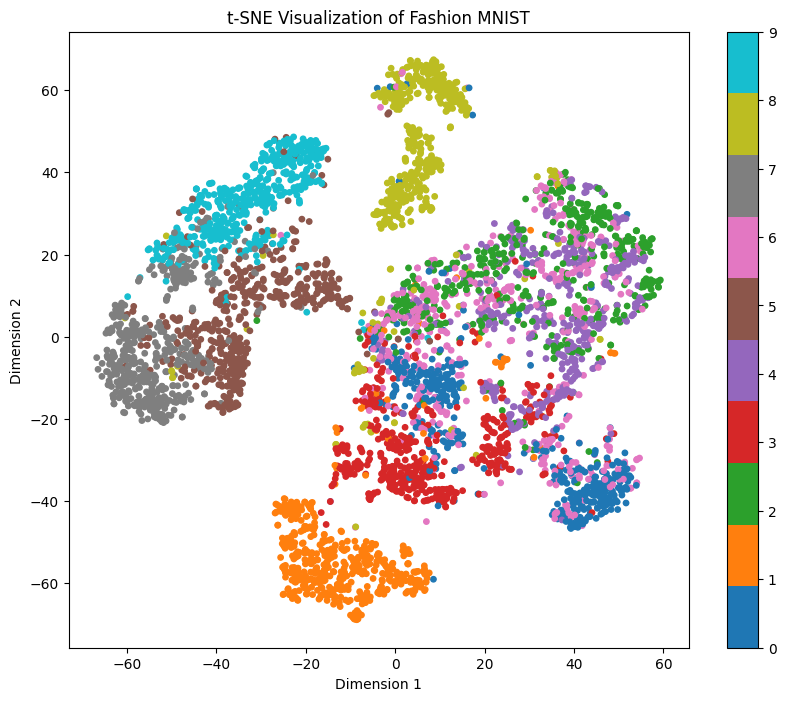

In [ ]:
# =========================
# TASK 4: t-SNE VISUALIZATION
# =========================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from sklearn.manifold import TSNE

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize images
train_images = train_images / 255.0

# Flatten images
train_images_flat = train_images.reshape((60000, 784))

# Use subset for faster processing
sample_data = train_images_flat[:5000]
sample_labels = train_labels[:5000]

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)

reduced_data = tsne.fit_transform(sample_data)

# Plot visualization
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    c=sample_labels,
    cmap='tab10',
    s=15
)

plt.colorbar(scatter)

plt.title('t-SNE Visualization of Fashion MNIST')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')

plt.show()

![My Image](Images/14.png)


Model Accuracy: 0.8828

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1000
           1       0.99      0.96      0.98      1000
           2       0.79      0.82      0.80      1000
           3       0.87      0.89      0.88      1000
           4       0.81      0.81      0.81      1000
           5       0.96      0.95      0.96      1000
           6       0.72      0.65      0.69      1000
           7       0.93      0.95      0.94      1000
           8       0.97      0.98      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



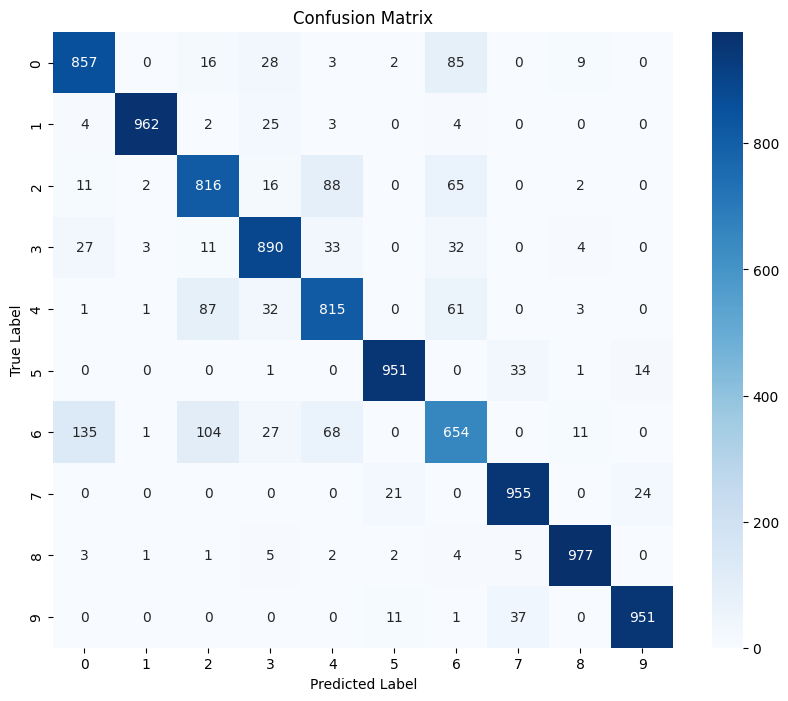

In [ ]:
# =========================
# TASK 5: MODEL EVALUATION
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images
train_images_flat = train_images.reshape((60000, 784))
test_images_flat = test_images.reshape((10000, 784))

# Best model: SVM with RBF kernel
svm = SVC(kernel='rbf', C=1)

# Train model
svm.fit(train_images_flat, train_labels)

# Predict test data
predictions = svm.predict(test_images_flat)

# Accuracy
accuracy = accuracy_score(test_labels, predictions)

print("\nModel Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, predictions))

# Confusion Matrix
cm = confusion_matrix(test_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

##### Submitted By-

- Name- Amulya Shrivastava
- Regd No- 2341019456
- Section- 23412F3
- Serial No- 59
- Subject- PFCD2 Major Assignment-03